# YouNiverse: Mapping YouTube's Hidden Communities

## Project Abstract

This project aims to uncover the hidden architecture of YouTube's content landscape. Instead of relying on explicit channel categories, we build a graph based on **audience overlap**. 

The core logic is this: for each user, we find the **Top-K channels** they comment on the most. We then create edges *only* between these Top-K channels. This creates a high-signal graph of true audience affinity.

This notebook documents the end-to-end pipeline by calling scripts from our `src` directory:

1.  **Data Loading:** Ingest channel and video metadata using `src.data.load`.
2.  **Graph Construction:** Stream comments to build the Top-K co-commenter graph using `src.scripts.process_data`.
3.  **Graph Analysis:** Normalize the graph (using our new commenter counts), run community detection, and calculate metrics using `src.models.analysis`.
4.  **Results:** Analyze and visualize the resulting communities.

## 1. Setup and Imports

First, we set up our environment, adding the `src` directory to the path and importing our custom-built modules.

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import our custom modules
from src.data import data_loader 
from src.scripts import process_data as data_processor
from src.models import model_analysis as model_analyzer

print("Successfully imported src modules.")

Successfully imported src modules.


### Configuration

We set our main analysis parameters here. These will be passed to our scripts.

In [2]:
# --- Parameters ---
MIN_SUBSCRIBERS = 200_000
MIN_EDGE_WEIGHT = 25
MAX_COMMENT_ROWS = 150_000_000 

# --- New Top-K Parameters ---
TOP_K_PER_AUTHOR = 5
MIN_CHANS_FOR_PAIRS = 2
AUTHOR_FLUSH_THRESHOLD = 500_000

# --- Normalization Parameters ---
NORM_ALPHA = 0.5
NORM_BETA = 1.0
USE_ENGAGEMENT_METRIC = True # Use commenter counts

# --- File Paths (relative to project root) ---
CHANNEL_METADATA_PATH = "data/raw/df_channels_en.tsv" 
VIDEO_METADATA_PATH = "data/raw/yt_metadata_helper.feather"

EDGES_OUT_PATH = "data/processed/channel_edges.csv"
CHECKPOINT_PATH = "data/processed/edges_checkpoint.pkl"
STATE_PATH = "data/processed/state.json"
DICT_PATH = "data/processed/dict_o.csv"

NODES_OUT_PATH = "data/processed/chan_graph_node_metrics.csv"
COMMUNITIES_OUT_PATH = "data/processed/chan_graph_community_summary.csv"
VIZ_OUT_PATH = "reports/figures/network_viz.png"

# Ensure processed/reports directories exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

print("Configuration and paths set.")

Configuration and paths set.


## 2. Data Loading and Preparation

First, we load the metadata we need to build our helper maps.
1.  **Channel Metadata:** To get subscriber counts for filtering.
2.  **Video Metadata:** To create a lookup map from `video_id` to `channel_id`.



In [3]:
# Load data using our loader script
dfChannels = pd.read_csv(CHANNEL_METADATA_PATH,sep='\t')
videoDf = data_loader.load_video_metadata(local_path=VIDEO_METADATA_PATH, columns=["display_id", "channel_id"])

'''# Create helper maps using our processing script
v2c_map = data_processor.build_video_to_channel_map(videoDf)
channel_subset_map = data_processor.get_channel_subset_map(dfChannels, MIN_SUBSCRIBERS)

del videoDf # Free up memory
'''

Loading Video Metadata...
Loaded 72,924,794 video records.


'# Create helper maps using our processing script\nv2c_map = data_processor.build_video_to_channel_map(videoDf)\nchannel_subset_map = data_processor.get_channel_subset_map(dfChannels, MIN_SUBSCRIBERS)\n\ndel videoDf # Free up memory\n'

## 3. Graph Construction: Streaming Comments

This is the most computationally intensive step. We call our `generate_edges` script.

As this probably would take too long to run on a personal computer without a graphic card, we created a notebook to be ran on a cloud computing platform like Google colab in src/data/data_loader.ipynb that creates edges and channel dictionary. They should be put in EDGES_OUT_PATH and DICT_PATH.

This function will stream comments, process them using the **Top-K logic**, and save both `channel_edges.csv` and the new `channel_commenter_counts.csv`.

It is also possible to create the graph only for videos published during a specific range of time. That is also shown in src/data/dataloader.ipynb. This will allow us to show the graph progress through time.

In [4]:
v2c_map = None
'''
edges_df = data_processor.generate_edges(
    v2c_map,
    EDGES_OUT_PATH,
    CHECKPOINT_PATH,
    STATE_PATH,
    DICT_PATH,
    max_rows=MAX_COMMENT_ROWS,
    top_k_per_author=TOP_K_PER_AUTHOR,
    min_chans_for_pairs=MIN_CHANS_FOR_PAIRS,
    author_flush_threshold=AUTHOR_FLUSH_THRESHOLD
)'''
edges_df = pd.read_csv(EDGES_OUT_PATH)
print(f"\nSuccessfully loaded {len(edges_df):,} edges.")
edges_df.head()


Successfully loaded 32,408,399 edges.


,src,dst,weight
0,UCBXNpF6k2n8dsI6nBH8q4sQ,UCM2ERkgV3P1_6MAyxa51rxA,29
1,UCBXNpF6k2n8dsI6nBH8q4sQ,UCpB959t8iPrxQWj7G6n0ctQ,98
2,UCBXNpF6k2n8dsI6nBH8q4sQ,UCtwD0AlYSlAYv7eXu8UxtEg,5
3,UCM2ERkgV3P1_6MAyxa51rxA,UCpB959t8iPrxQWj7G6n0ctQ,431
4,UCM2ERkgV3P1_6MAyxa51rxA,UCtwD0AlYSlAYv7eXu8UxtEg,10


## 4. Graph Analysis Pipeline

Now we run the main analysis pipeline. Let us find communities of similar channels based on audience. 

We will normalize our graph. The problem now is that two big channels will automatically have an edge between them with a high enough weight to shadow two smaller channels with the same edge weight but which is way more representative of channel similarity proportionally to their size. 

For example, Channel 1 and Channel 2 both have 500k total commenters that we scraped from the data. The edge weight is 10k meaning 10k of these users commented both on videos from channel 1 and channel 2. Proportionally to the channel size this is not a huge value. <br/>
On the other hand we have Channel 3 and 4 which both have 10k commenters. This time the edge weight is 5k. Meaning approximately half of their audience is shared! Edge weight is then not the best indicator channel similarity <br/> <br/>
Knowing this, we normalize edge weight to get more of a "similarity score" and find more niche communities.

In [5]:

edges_filtered, channels_indexed = model_analyzer.filter_edges(
    edges_df, dfChannels, MIN_SUBSCRIBERS, MIN_EDGE_WEIGHT
)

commenter_counts = data_loader.load_commenter_counts(DICT_PATH)

edges_normalized = model_analyzer.normalize_edges(
    edges_filtered, 
    channels_indexed, 
    commenter_counts, 
    alpha=0.3, 
    beta=NORM_BETA, 
    use_engagement=USE_ENGAGEMENT_METRIC
)


G = model_analyzer.build_graph(edges_normalized, channels_indexed)

LCC, communities, node_df, comm_summary = model_analyzer.find_communities(
    G, nodes_out_path=NODES_OUT_PATH, comm_out_path=COMMUNITIES_OUT_PATH
)

Filtering edges: >200000 subs, >25 weight.
Filtered down to 572,732 edges.
Loading commenter counts from data/processed/dict_o.csv...
Loaded 129,996 channel commenter counts.
Normalizing edge weights...
Using commenters (Top-K) (median=98) for normalization.
Building graph from normalized edges...
Graph built: 19,129 nodes, 572,732 edges
Finding Largest Connected Component (LCC)...
LCC:   19,064 nodes, 572,671 edges  (99.7% of nodes)
Detecting communities using Louvain...
Found 52 communities (modularity: 0.655)
Calculating node metrics (PageRank, Strength)...

✓ Saved node metrics and community summary.


## 5. Results and Interpretation

Our pipeline is complete. The results are saved in `data/processed/`. We can now load them for analysis.

### Result 1: Top 10 Largest Communities

This table shows the largest "galaxies" we found, sorted by the number of channels they contain.

In [6]:
print("Top 10 Largest Communities:")
print(comm_summary.head(10).to_string(index=False))

Top 10 Largest Communities:
 community  n_nodes  total_strength  avg_degree  avg_strength
         0     3166        18691851   52.885344   5903.932723
        17     3139        41072907   93.387066  13084.710736
         9     3104        15861957   56.278351   5110.166559
        20     2219        24178088   80.957639  10895.938711
        10     1874        12936205   66.657951   6902.990928
        15     1108         3331357   35.462094   3006.639892
        16     1016         4203464   44.836614   4137.267717
         5      584         3414801   45.039384   5847.261986
         7      557         1236039   28.718133   2219.100539
        29      535          999220   25.014953   1867.700935


In [7]:
totalLength = 0
communities.sort()


In [8]:
filtered = []
for i in range(len(communities)):
    if len(communities[i])>3:
        filtered.append(communities[i])
communities = filtered

### Result 2: Top 10 Most Influential Channels

This table shows the top 10 channels ranked by **PageRank**. PageRank identifies channels that are connected to *other* influential channels. These are the "super-connectors" in our YouNiverse.

In [9]:
print("Top 10 Channels by PageRank:")
print(node_df.nlargest(10, "pagerank")[
    ["name_cc", "category_cc", "subscribers_cc", "community", "degree", "pagerank"]
].to_string(index=False))

Top 10 Channels by PageRank:
         name_cc          category_cc  subscribers_cc  community  degree  pagerank
       PewDiePie               Gaming       101000000         17    8641  0.019703
        T-Series                Music       112139463          0    4123  0.010550
Technical Guruji Science & Technology        13979890          0    2470  0.005965
          DanTDM               Gaming        22100000         17    3311  0.005845
      Markiplier               Gaming        24400000         17    3781  0.005361
   jacksepticeye               Gaming        22833014         17    3512  0.005175
     PopularMMOs               Gaming        16900000         17    2779  0.004423
       Jake Paul       People & Blogs        19600000         20    2999  0.004404
  The ACE Family       People & Blogs        17600000         20    2696  0.004245
          SMTOWN                Music        19800000          9    2469  0.004211


### Result 3: Deep Dive into Community Profiles

We now call our analysis script to analyze the top communities. This helps us put a name and a theme to our algorithmically-defined clusters.

In [10]:
# Run the analysis script
model_analyzer.analyze_communities(LCC, node_df, communities, max_show=70)

--- Deep Dive into Top 5 Communities ---
COMMUNITY 0
Size: 3166 nodes, 76181 edges
Top category: Entertainment (734/3166) 
--------------------------------------------------------------------------------
Categories:
  Entertainment         734 (23.2%)
  Music                 502 (15.9%)
  Education             380 (12.0%)
  Howto & Style         348 (11.0%)
  People & Blogs        294 (9.3%)
--------------------------------------------------------------------------------
Top 5 Channels (by Subscribers):
          name_cc          category_cc  strength  subscribers_cc
         T-Series                Music   1053744       112139463
 Technical Guruji Science & Technology    683916        13979890
Zee Music Company                Music    433101        43451109
    Speed Records                Music    309897        25502155
       Wave Music                Music    273800        27900000

COMMUNITY 1
Size: 33 nodes, 154 edges
Top category: Music (29/33) 
---------------------------------

### Result 4: Network Visualization

Finally, we call our visualization script to generate and save a plot of the graph.

**Nodes** are colored by their community and sized by their strength and the legend shows us the top youtuber by community.

Generating network visualization...
Visualization subgraph: 154 nodes, 1544 edges
✓ Saved reports/figures/network_viz.png


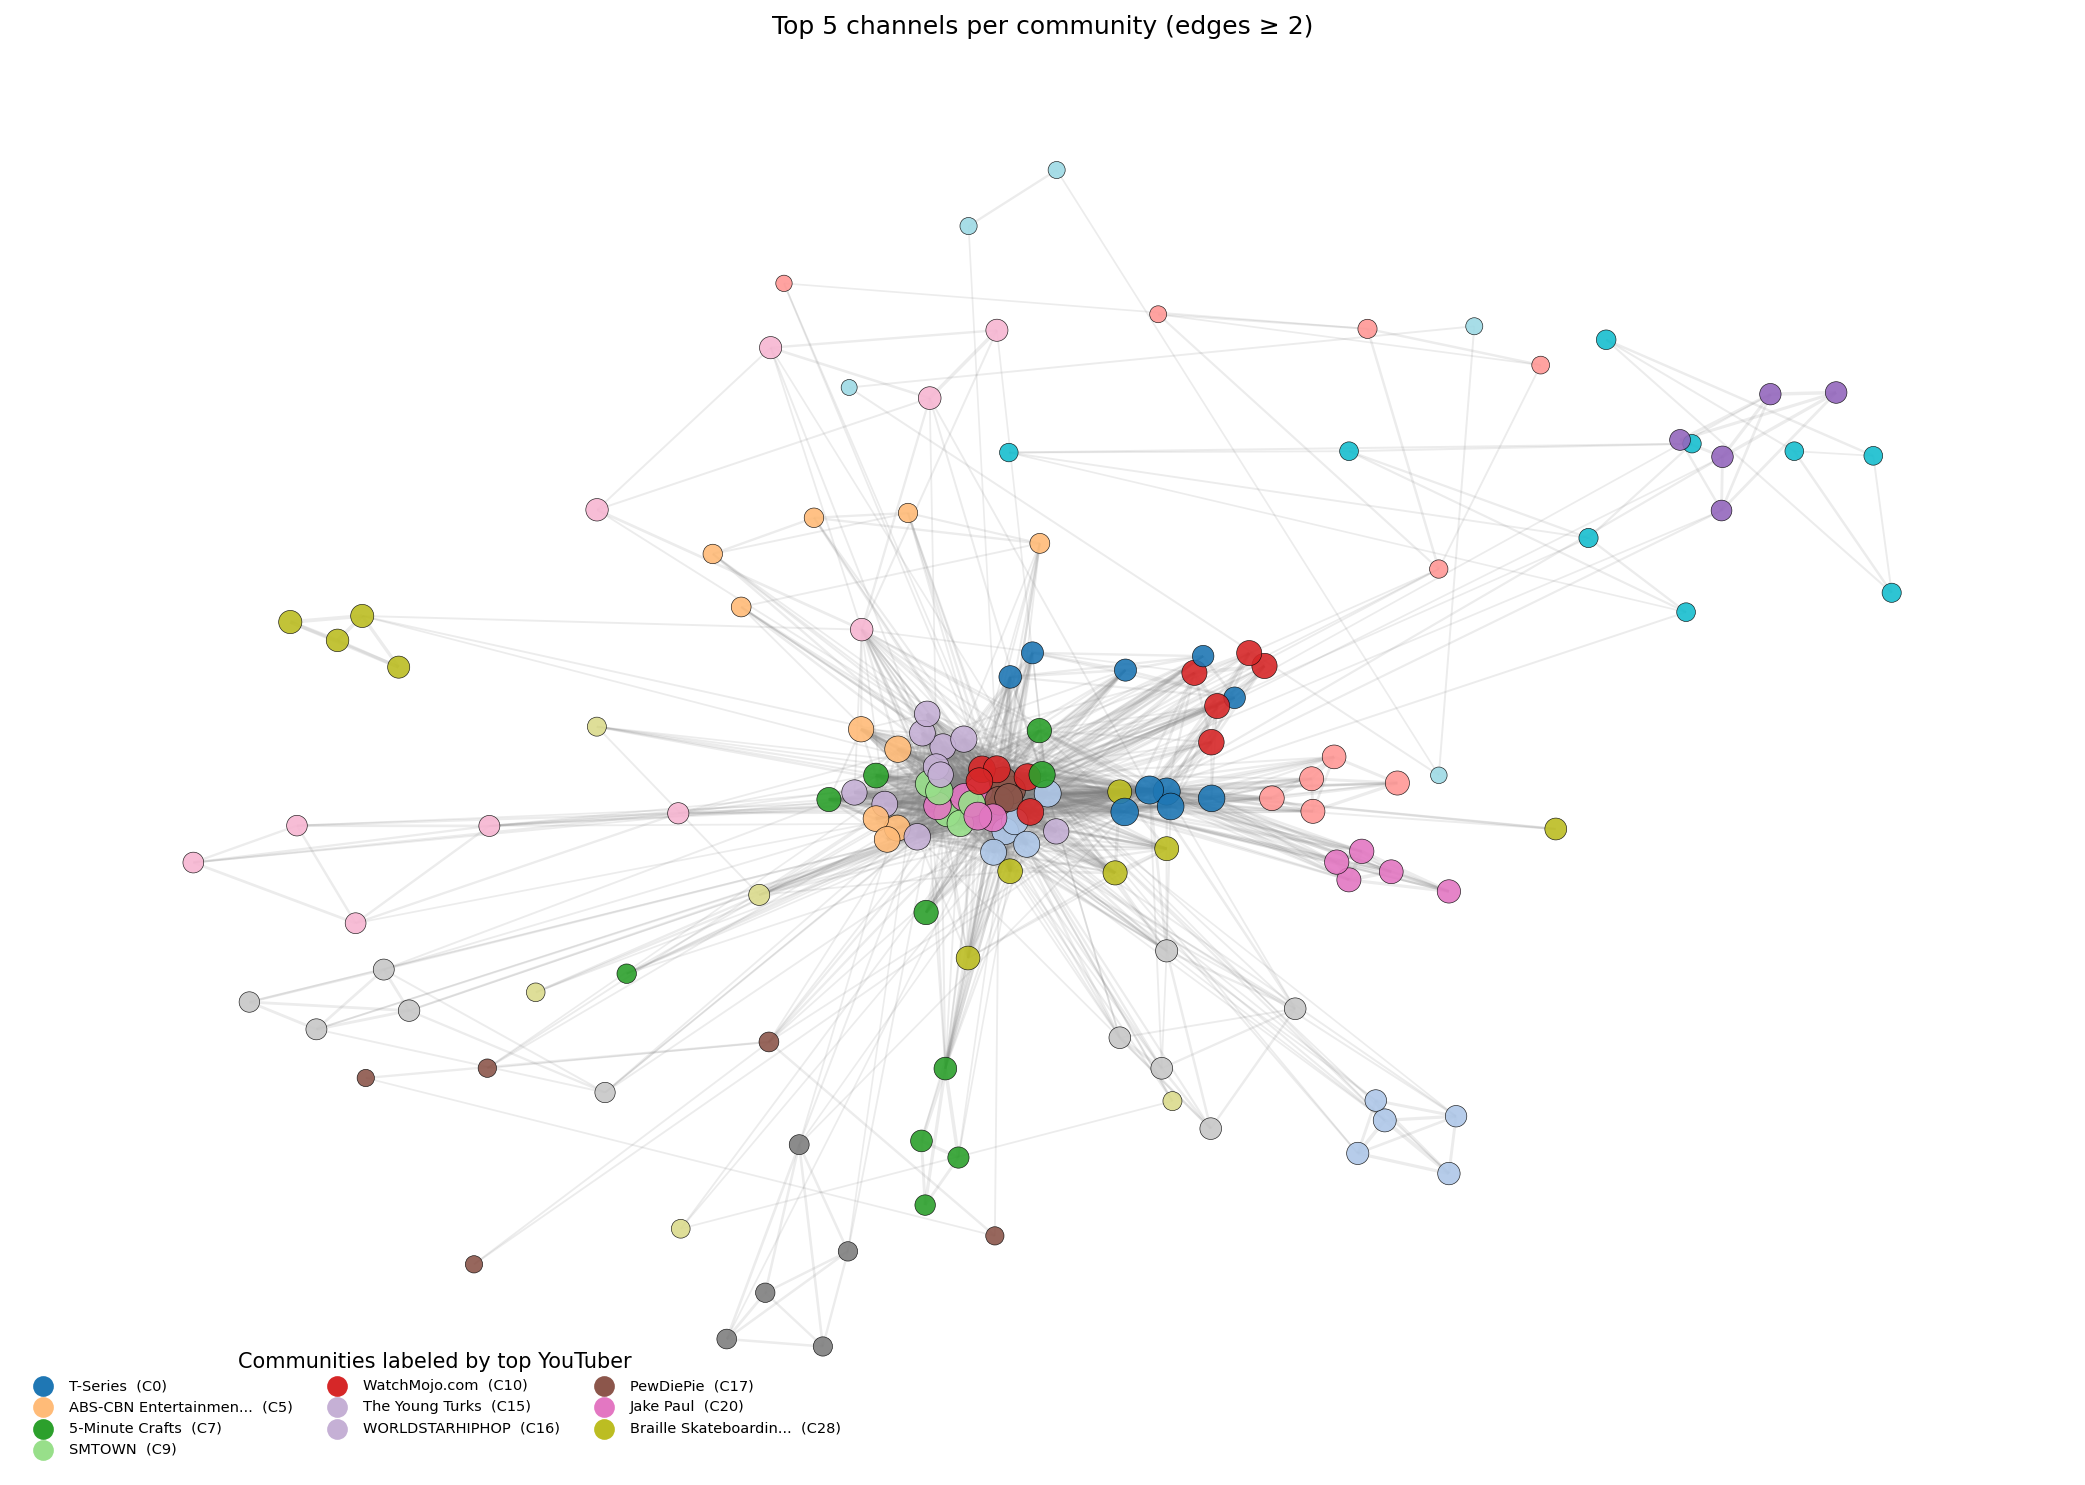

In [11]:
model_analyzer.visualize_network(
    LCC, 
    communities, 
    node_df, 
    n_per_comm=5,
    min_comm_nodes=500,
    viz_out_path=VIZ_OUT_PATH, 
)

In [12]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def visualize_core_network(LCC, communities, node_df, viz_out_path, 
                           n_per_comm=15, 
                           num_top_communities=5, 
                           weight_threshold=5, 
                           seed=42):
    """
    Zooms into the 'Galactic Core' by only graphing the largest communities.
    Filters out peripheral/satellite galaxies.
    """
    print(f"Focusing on the top {num_top_communities} largest galaxies...")

    # 1. Sort communities by size (number of nodes) to identify 'The Core'
    # This filters out the isolated constellations on the periphery.
    sorted_communities = sorted(communities, key=len, reverse=True)
    core_communities = sorted_communities[:num_top_communities]
    
    # Map nodes to their community ID
    node2comm = {node: cid for cid, comm in enumerate(core_communities) for node in comm}
    core_nodes_all = set(node2comm.keys())

    # 2. Calculate 'Gravitational Strength' (Degree Centrality)
    strength = {u: sum(d.get("weight_raw", 0) for _, d in LCC[u].items()) for u in core_nodes_all}

    # 3. Channel Metadata Helper
    meta = node_df.set_index("channel_id").to_dict(orient="index")
    def name_of(uid):
        nm = (meta.get(uid, {}) or {}).get("name_cc") or uid
        return nm if len(str(nm)) > 0 else uid

    # 4. Select the most 'Supermassive' nodes from each core community
    selected = set()
    top_per_comm = {}
    for cid, nodes_c in enumerate(core_communities):
        # Sort nodes in this community by strength
        top_nodes = sorted(nodes_c, key=lambda u: strength.get(u, 0), reverse=True)
        selected.update(top_nodes[:n_per_comm])
        top_per_comm[cid] = name_of(top_nodes[0])

    # 5. Create the Edge Subgraph (The Gravitational Bonds)
    # We increase weight_threshold to remove faint 'space dust' and see the core structure
    edges_to_keep = [
        (u, v) for u, v, d in LCC.edges(data=True)
        if u in selected and v in selected and d.get("weight_raw", 0) >= weight_threshold
    ]
    
    H = LCC.edge_subgraph(edges_to_keep).copy()
    H.remove_nodes_from(list(nx.isolates(H)))

    print(f"Core visualization: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

    # 6. Layout: Force-directed (Spring) layout with higher 'k' to spread the core nodes
    pos = nx.spring_layout(H, weight="weight_raw", seed=seed, k=1.5, iterations=100)
    
    # 7. Rendering
    plt.figure(figsize=(16, 12), facecolor='white')
    
    # Colors for the core galaxies
    comm_colors = plt.cm.Set1(np.linspace(0, 1, num_top_communities))
    node_colors = [comm_colors[node2comm[n]] for n in H.nodes()]
    node_sizes = [50 * np.log10(strength.get(n, 1) + 10) for n in H.nodes()]

    nx.draw_networkx_edges(H, pos, width=0.5, alpha=0.2, edge_color="black")
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes,
                           edgecolors="black", linewidths=0.5, alpha=0.8)

    # Label the 'Supermassive Black Holes' (Top nodes)
    # We only label the top 2-3 per community to keep the core legible
    label_targets = {}
    for nodes_c in core_communities:
        top_3 = sorted(nodes_c, key=lambda u: strength.get(u, 0), reverse=True)[:3]
        for node in top_3:
            if node in H:
                label_targets[node] = name_of(node)
                
    nx.draw_networkx_labels(H, pos, labels=label_targets, font_size=8, font_weight='bold')

    plt.title(f"Voyage into the Core: Interaction between Top {num_top_communities} Galaxies", fontsize=15)
    plt.axis("off")
    plt.savefig(viz_out_path, dpi=300, bbox_inches="tight")
    plt.show()

Focusing on the top 8 largest galaxies...
Core visualization: 80 nodes, 460 edges


/var/folders/ss/f94jbyss3hzbdfdxp4z70qwh0000gn/T/ipykernel_88476/876941450.py:83: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_out_path, dpi=300, bbox_inches="tight")
/var/folders/ss/f94jbyss3hzbdfdxp4z70qwh0000gn/T/ipykernel_88476/876941450.py:83: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_out_path, dpi=300, bbox_inches="tight")
/var/folders/ss/f94jbyss3hzbdfdxp4z70qwh0000gn/T/ipykernel_88476/876941450.py:83: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_out_path, dpi=300, bbox_inches="tight")
/var/folders/ss/f94jbyss3hzbdfdxp4z70qwh0000gn/T/ipykernel_88476/876941450.py:83: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_out_path, dpi=300, bbox_inches="tight")
/Users/adam/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 508

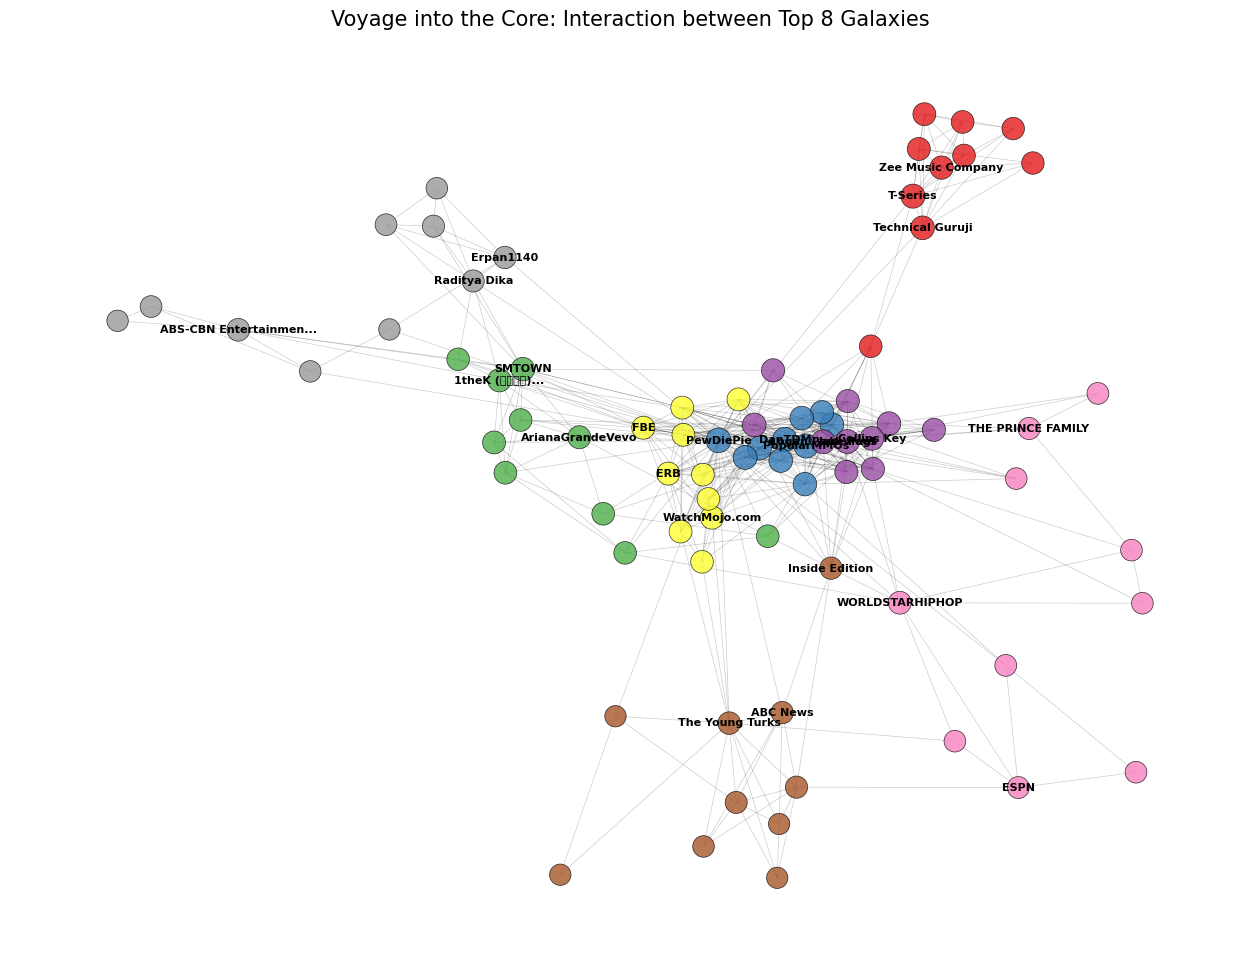

In [13]:
visualize_core_network(
    LCC, 
    communities, 
    node_df, 
    n_per_comm=10,
    num_top_communities=8,
    viz_out_path=VIZ_OUT_PATH,
    weight_threshold=1000
)

In [14]:
import networkx as nx
import numpy as np
from pyvis.network import Network
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

def visualize_core_interactive(LCC, communities, node_df, html_out_path, num_top_communities=5, n_per_comm=20, seed=42):
    print(f"🔭 Zooming into the top {num_top_communities} galaxies...")
    
    # --- 1. Identify the 'Core' Galaxies ---
    # Sort communities by size to find the dominant structures
    sorted_communities = sorted(communities, key=len, reverse=True)
    core_communities = sorted_communities[:num_top_communities]
    
    # Map nodes to their core community ID
    node2comm = {node: cid for cid, comm in enumerate(core_communities) for node in comm}
    core_nodes_all = set(node2comm.keys())
    
    # Strength & Metadata logic
    strength = {u: sum(d.get("weight_raw", 0) for _, d in LCC[u].items()) for u in core_nodes_all}
    meta = node_df.set_index("channel_id").to_dict(orient="index")

    def name_of(uid):
        nm = (meta.get(uid, {}) or {}).get("name_cc") or uid
        return str(nm) if len(str(nm)) > 0 else str(uid)

    # --- 2. Select Representative 'Stars' from Core Galaxies ---
    selected = set()
    for nodes_c in core_communities:
        # Sort by strength to find 'Black Hole' channels
        top_nodes = sorted(nodes_c, key=lambda u: strength.get(u, 0), reverse=True)
        selected.update(top_nodes[:n_per_comm])

    # Filter subgraph: only keep bonds within the core that meet the threshold
    edges_to_keep = [(u, v) for u, v, d in LCC.edges(data=True) 
                     if u in selected and v in selected and d.get("weight_raw", 0) >= 3]
    H = LCC.edge_subgraph(edges_to_keep).copy()
    H.remove_nodes_from(list(nx.isolates(H)))

    # --- 3. Radial Expansion for the Galactic Bulge ---
    # We use a higher 'k' to push the dense core nodes apart
    pos = nx.spring_layout(H, weight="weight_raw", seed=seed, k=5.0, iterations=200)
    
    center_x = np.mean([p[0] for p in pos.values()])
    center_y = np.mean([p[1] for p in pos.values()])
    
    expanded_pos = {}
    distances = {node: np.sqrt((p[0]-center_x)**2 + (p[1]-center_y)**2) for node, p in pos.items()}
    max_dist = max(distances.values()) if distances else 1.0
    
    for node, (x, y) in pos.items():
        dist = distances[node]
        # Aggressive expansion for nodes caught in the 'central cluster'
        norm_dist = dist / max_dist
        expansion_factor = 1.0 + (3.5 * (1 - norm_dist)**2)
        
        expanded_pos[node] = (center_x + (x - center_x) * expansion_factor, 
                             center_y + (y - center_y) * expansion_factor)
    
    pos = expanded_pos
    x_range = max(p[0] for p in pos.values()) - min(p[0] for p in pos.values())
    y_range = max(p[1] for p in pos.values()) - min(p[1] for p in pos.values())

    # --- 4. Interactive Export (No Physics) ---
    net = Network(height='850px', width='100%', bgcolor='#ffffff', font_color='black', cdn_resources='remote')
    net.toggle_physics(False) 

    # Colors for core galaxies only
    comm_colors = plt.cm.Set1(np.linspace(0, 1, num_top_communities))
    SPREAD = 4500 

    for node in H.nodes():
        cid = node2comm[node]
        color = mcolors.to_hex(comm_colors[cid])
        
        # Coordinate mapping
        x = ((pos[node][0] - min(p[0] for p in pos.values())) / x_range - 0.5) * SPREAD
        y = ((pos[node][1] - min(p[1] for p in pos.values())) / y_range - 0.5) * SPREAD
        
        # Attention Inequality scaling
        size = 12 + (np.log10(strength.get(node, 1) + 1) * 15)
        
        net.add_node(
            node, x=x, y=y, label=name_of(node), color=color, size=size,
            title=f"Channel: {name_of(node)}<br>Galaxy Cluster: {cid}",
            borderWidth=1.5, font={'size': 20, 'strokeWidth': 3, 'strokeColor': '#ffffff'}
        )

    for u, v, d in H.edges(data=True):
        w = d.get("weight_raw", 1)
        # Visually represent gravitational bond strength
        width = 0.8 + (np.log10(w) * 2.0)
        net.add_edge(u, v, width=width, color='rgba(150,150,150,0.25)')

    # --- 5. Legend for the Galactic Giants ---
    legend_html = """
    <div style="position: absolute; top: 15px; left: 15px; width: 230px; background: rgba(255,255,255,0.9); 
                border: 2px solid #333; padding: 15px; font-family: 'Segoe UI', sans-serif; z-index: 1000; border-radius: 10px;">
        <b style="font-size: 14px; display: block; margin-bottom: 10px; border-bottom: 1px solid #333;">Dominant Galactic Hubs</b>
    """
    for cid, nodes_c in enumerate(core_communities):
        best = max(nodes_c, key=lambda u: strength.get(u, 0))
        color = mcolors.to_hex(comm_colors[cid])
        name = name_of(best)
        legend_html += f'<div style="margin-bottom: 6px;"><span style="color:{color}; font-size: 18px;">●</span> <b>Hub {cid}:</b> {name}</div>'
    legend_html += "</div>"

    net.save_graph(html_out_path)
    with open(html_out_path, 'r', encoding='utf-8') as f:
        content = f.read().replace('<body>', f'<body>{legend_html}')
    with open(html_out_path, 'w', encoding='utf-8') as f:
        f.write(content)

    print(f"✅ Core-only interactive map saved: {html_out_path}")

In [15]:
visualize_core_interactive(
    LCC, 
    communities, 
    node_df, 
    num_top_communities=5,
    n_per_comm=10,
    html_out_path='b.html'
)

🔭 Zooming into the top 5 galaxies...
✅ Core-only interactive map saved: b.html


## 6. Topic Detection for Communities

Now we apply topic detection to identify the themes within each community. This uses LDA (Latent Dirichlet Allocation) following the methodology from Lab 9.

In [16]:
# Install required packages if not already installed
# !pip install spacy gensim
# !python -m spacy download en_core_web_sm

import spacy

# Load spacy model
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    print("✓ Spacy model loaded")
except:
    print("⚠️  Run: python -m spacy download en_core_web_sm")
    nlp = None

✓ Spacy model loaded


### Load video metadata for topic detection

In [17]:
# Load video metadata for topic detection
# Stream directly from the YouNiverse dataset zip file
# Only loads videos from channels in our communities (efficient)

# Sort communities by size (largest first) for better analysis
communities_sorted = sorted(communities, key=len, reverse=True)
print("Top 10 communities by size:")
for i, comm in enumerate(communities_sorted[:10]):
    print(f"  Community {i}: {len(comm):,} channels")

# Collect channel IDs from the LARGEST communities
n_communities_to_analyze = 10
all_channels = set()
for i in range(min(n_communities_to_analyze, len(communities_sorted))):
    all_channels.update(communities_sorted[i])

print(f"\nNeed videos from {len(all_channels)} unique channels across {n_communities_to_analyze} largest communities")

# Stream videos from the zip file (no extraction needed)
video_df = data_loader.stream_video_metadata_from_zip(
    zip_path='data/youniverse-dataset.zip',
    channel_filter=all_channels,
    max_videos_per_channel=100  # Adjust as needed (50=fast, 200=more data)
)

if len(video_df) == 0:
    print("\nError: No videos loaded. Check that data/youniverse-dataset.zip exists.")
else:
    print(f"\n✓ Successfully loaded {len(video_df):,} videos")
    print(f"  Columns: {list(video_df.columns)}")
    print(f"  Ready for topic detection!")

Top 10 communities by size:
  Community 0: 3,166 channels
  Community 1: 3,139 channels
  Community 2: 3,104 channels
  Community 3: 2,219 channels
  Community 4: 1,874 channels
  Community 5: 1,108 channels
  Community 6: 1,016 channels
  Community 7: 584 channels
  Community 8: 557 channels
  Community 9: 535 channels

Need videos from 17302 unique channels across 10 largest communities
Streaming video metadata from data/youniverse-dataset.zip...
Filtering for 17302 channels...
Reading yt_metadata_en.jsonl.gz from zip...
  Processed 12,000,000 records, kept 249,658...
  Processed 62,000,000 records, kept 1,330,024...

Loaded 1,568,611 videos from 17302 channels
Processed 72,924,794 total records

✓ Successfully loaded 1,568,611 videos
  Columns: ['channel_id', 'title', 'description', 'tags']
  Ready for topic detection!


### Analyze topics for each community

In [18]:
# Analyze top communities
# Reload module to ensure latest code is used
import importlib
importlib.reload(model_analyzer)

n_communities_to_analyze = 10
community_topics = {}

# Verify video_df has the right columns
print(f"Video DataFrame columns: {list(video_df.columns)}")
print(f"Video DataFrame shape: {video_df.shape}")

# Use communities_sorted (sorted by size, largest first)
for i, community in enumerate(communities_sorted[:n_communities_to_analyze]):
    print(f"\n{'='*80}")
    print(f"COMMUNITY {i} (size: {len(community)} channels)")
    print(f"{'='*80}\n")
    
    result = model_analyzer.categoryDetect(
        community=community,
        video_metadata_df=video_df,
        k_channels=25,              # Sample 25 channels per community
        n_videos_per_channel=100,   # Up to 100 videos per channel
        n_topics=6,                 # Extract 6 topics
        text_mode='combined',       # Use title + tags + truncated desc (TA recommended)
        desc_max_chars=200,         # Truncate descriptions to 200 chars
        min_wordcount=5,
        max_freq=0.4,               # More frequent words are less likely to be included
        passes=20,                  # More passes means more iterations
        seed=42,
        nlp=nlp
    )
    
    community_topics[i] = result
    print("\n")

Video DataFrame columns: ['channel_id', 'title', 'description', 'tags']
Video DataFrame shape: (1568611, 4)

COMMUNITY 0 (size: 3166 channels)

=== Topic Detection for Community (3166 channels) ===
Sampled 25 channels from community
Sampled 2298 videos
Using combined mode: title + tags + description (truncated to 200 chars)
Processing 2298 texts with spacy...
Preprocessed 2298 documents
Adding bigrams...
Creating dictionary and corpus...
Number of unique tokens: 3255
Number of documents: 2298
Training LDA model with 6 topics...

Detected 6 topics:

Topic 0: movie, app, cricket, hindi, housefull
Topic 1: free, energy, free_energy, video, generator
Topic 2: Bhangra, interview, ipl, question, answer
Topic 3: current, affair, current_affair, video, exam
Topic 4: hindi, rhyme, ayurveda, sanyasi, home
Topic 5: song, punjabi, new, late, punjabi_song



COMMUNITY 1 (size: 3139 channels)

=== Topic Detection for Community (3139 channels) ===
Sampled 25 channels from community
Sampled 2388 video

### Compare detected topics with official YouTube categories

In [19]:
# Compare detected topics with official categories
for comm_id in range(min(3, len(communities_sorted))):
    community = communities_sorted[comm_id]
    
    # Get official categories from node_df
    comm_nodes = node_df[node_df['channel_id'].isin(community)]
    categories = comm_nodes['category_cc'].value_counts()
    
    print(f"\n{'='*80}")
    print(f"Community {comm_id}")
    print(f"{'='*80}")
    
    print(f"\nOfficial YouTube Category Distribution:")
    for cat, count in categories.head(5).items():
        pct = count / len(community) * 100
        print(f"  {cat:20s} {count:4d} channels ({pct:5.1f}%)")
    
    if comm_id in community_topics and community_topics[comm_id]['topics']:
        print(f"\nDetected Topics (LDA):")
        for topic_id, topic_words in enumerate(community_topics[comm_id]['topics']):
            words = ', '.join([word for word, _ in topic_words[:5]])
            print(f"  Topic {topic_id + 1}: {words}")
    
    print()


Community 0

Official YouTube Category Distribution:
  Entertainment         734 channels ( 23.2%)
  Music                 502 channels ( 15.9%)
  Education             380 channels ( 12.0%)
  Howto & Style         348 channels ( 11.0%)
  People & Blogs        294 channels (  9.3%)

Detected Topics (LDA):
  Topic 1: movie, app, cricket, hindi, housefull
  Topic 2: free, energy, free_energy, video, generator
  Topic 3: Bhangra, interview, ipl, question, answer
  Topic 4: current, affair, current_affair, video, exam
  Topic 5: hindi, rhyme, ayurveda, sanyasi, home
  Topic 6: song, punjabi, new, late, punjabi_song


Community 1

Official YouTube Category Distribution:
  Gaming               1520 channels ( 48.4%)
  Entertainment         629 channels ( 20.0%)
  Film and Animation    257 channels (  8.2%)
  Comedy                202 channels (  6.4%)
  People & Blogs        141 channels (  4.5%)

Detected Topics (LDA):
  Topic 1: fortnite, story, Fortnite, kid, spore
  Topic 2: minecraft, 

### Visualize topics with pyLDAvis

In [20]:
# Display topics nicely for each community
def display_topics(community_topics):
    for comm_id, result in community_topics.items():
        print(f"\n{'='*60}")
        print(f"COMMUNITY {comm_id} - Detected Topics")
        print(f"{'='*60}")
        print(f"Videos analyzed: {result.get('n_videos', 0)}")
        print(f"Channels sampled: {len(result.get('sampled_channels', []))}")
        
        topics = result.get('topics', [])
        if not topics:
            print("No topics detected")
            continue
            
        for topic_id, topic_words in enumerate(topics):
            print(f"\n  Topic {topic_id + 1}:")
            top_words = [f"{word} ({weight:.2f})" for word, weight in topic_words[:5]]
            print(f"    {', '.join(top_words)}")

display_topics(community_topics)


COMMUNITY 0 - Detected Topics
Videos analyzed: 2298
Channels sampled: 25

  Topic 1:
    movie (0.11), app (0.02), cricket (0.02), hindi (0.02), housefull (0.01)

  Topic 2:
    free (0.02), energy (0.02), free_energy (0.01), video (0.01), generator (0.01)

  Topic 3:
    Bhangra (0.03), interview (0.03), ipl (0.02), question (0.02), answer (0.01)

  Topic 4:
    current (0.06), affair (0.06), current_affair (0.03), video (0.02), exam (0.01)

  Topic 5:
    hindi (0.04), rhyme (0.03), ayurveda (0.02), sanyasi (0.02), home (0.02)

  Topic 6:
    song (0.08), punjabi (0.06), new (0.03), late (0.02), punjabi_song (0.02)

COMMUNITY 1 - Detected Topics
Videos analyzed: 2388
Channels sampled: 25

  Topic 1:
    fortnite (0.03), story (0.02), Fortnite (0.02), kid (0.01), spore (0.01)

  Topic 2:
    minecraft (0.06), little (0.05), kelly (0.03), little_kelly (0.02), Minecraft (0.02)

  Topic 3:
    pokemon (0.07), scammer (0.04), fortnite (0.04), scamme (0.03), battle (0.03)

  Topic 4:
    

### Interactive Topic Visualization with pyLDAvis

In [32]:
# Install pyLDAvis if needed (uncomment and run once)
# !pip install pyldavis

import warnings
warnings.filterwarnings('ignore')  # Suppress multiprocessing warnings

import pyLDAvis
import pyLDAvis.gensim_models

# Enable notebook visualization
pyLDAvis.enable_notebook()

# Visualize topics for a specific community
comm_id = 0  # Change this to visualize different communities (0, 1, 2, ...)

if comm_id in community_topics:
    result = community_topics[comm_id]
    if result.get('model') and result.get('corpus') and result.get('dictionary'):
        print(f"Preparing visualization for Community {comm_id}...")
        
        # Prepare the visualization data
        vis_data = pyLDAvis.gensim_models.prepare(
            result['model'], 
            result['corpus'], 
            result['dictionary'],
            sort_topics=False
        )
        
        # Save to HTML file (always works)
        html_path = f'reports/figures/lda_community_{comm_id}.html'
        pyLDAvis.save_html(vis_data, html_path)
        print(f"✓ Saved interactive visualization to: {html_path}")
        print(f"  Open this file in your browser to see the visualization!")
        
        # Try to display inline (may not work in all environments)
        try:
            pyLDAvis.display(vis_data)
        except Exception as e:
            print(f"\\n(Inline display not available: {e})")
            print("Use the HTML file instead.")
    else:
        print(f"Community {comm_id} missing model/corpus/dictionary")
else:
    print(f"Community {comm_id} not found in results")

Preparing visualization for Community 9...
✓ Saved interactive visualization to: reports/figures/lda_community_9.html
  Open this file in your browser to see the visualization!


Exception ignored in: <function ResourceTracker.__del__ at 0x1042ce480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105f6e480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111126480>
Traceback (most recent call last

### Save topic detection results

In [22]:
# Create summary DataFrame
summary_data = []

for comm_id, result in community_topics.items():
    if result['topics']:
        # Get top 5 words from each topic
        topic_summaries = []
        for topic_words in result['topics']:
            top_words = ', '.join([word for word, _ in topic_words[:5]])
            topic_summaries.append(top_words)
        
        summary_data.append({
            'community_id': comm_id,
            'n_channels': len(communities_sorted[comm_id]),
            'n_videos_analyzed': result['n_videos'],
            'n_topics': len(result['topics']),
            'topics': ' | '.join(topic_summaries)
        })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('data/processed/community_topics_summary.csv', index=False)

print("✓ Results saved to data/processed/community_topics_summary.csv\n")
summary_df

✓ Results saved to data/processed/community_topics_summary.csv



,community_id,n_channels,n_videos_analyzed,n_topics,topics
0,0,3166,2298,6,"movie, app, cricket, hindi, housefull | free, ..."
1,1,3139,2388,6,"fortnite, story, Fortnite, kid, spore | minecr..."
2,2,3104,2314,6,"simply, Headhunterz, Pop, Icona, live | projec..."
3,3,2219,2340,6,"food, eat, sugar, recipe, pop | makeup, luxury..."
4,4,1874,2358,6,"vape, short, future, film, future_short | dokk..."
5,5,1108,2500,6,"fox, earth, flat, flat_earth, sport | yoga, st..."
6,6,1016,2233,6,"nike, sneaker, air, app, shoe | missy, footbal..."
7,7,584,2346,6,"food, street, mary, bautista, mary_bautista | ..."
8,8,557,2215,6,"Thomas, Friends, animal, cute, Toy | song, sto..."
9,9,535,2375,6,"gta, car, art, paint, Car | disney, world, nee..."
